In [8]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function
import pickle

In [21]:
filename = "./solutions/test2_coupling_sameinitemp.pkl"
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
Q = functionspace(domain, ("DG", 0))
W = functionspace(domain, ("CG", 1))
hw = Function(V)
phi = Function(Q)
T_i = Function(W)
T_w = Function(W)
p = Parameter(domain)

In [22]:
len(data_Annika["h_w"])

58

In [27]:
interval = data_Annika["saving_interval"]
t_obs = -1
time = data_Annika["times"][t_obs]
hw.x.array[:] = data_Annika["h_w"][t_obs]
phi.x.array[:] = data_Annika["phi"][t_obs]
T_i.x.array[:] = data_Annika["T_i"][t_obs]
T_w.x.array[:] = data_Annika["T_w"][t_obs]
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
Ti = eval_fct_on_grid(grid, T_i, domain).reshape((nz, nx))
Tw = eval_fct_on_grid(grid, T_w, domain).reshape((nz, nx))
h_c = pressure_head * (pressure_head < 0)
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, p.alpha.value, p.N.value)

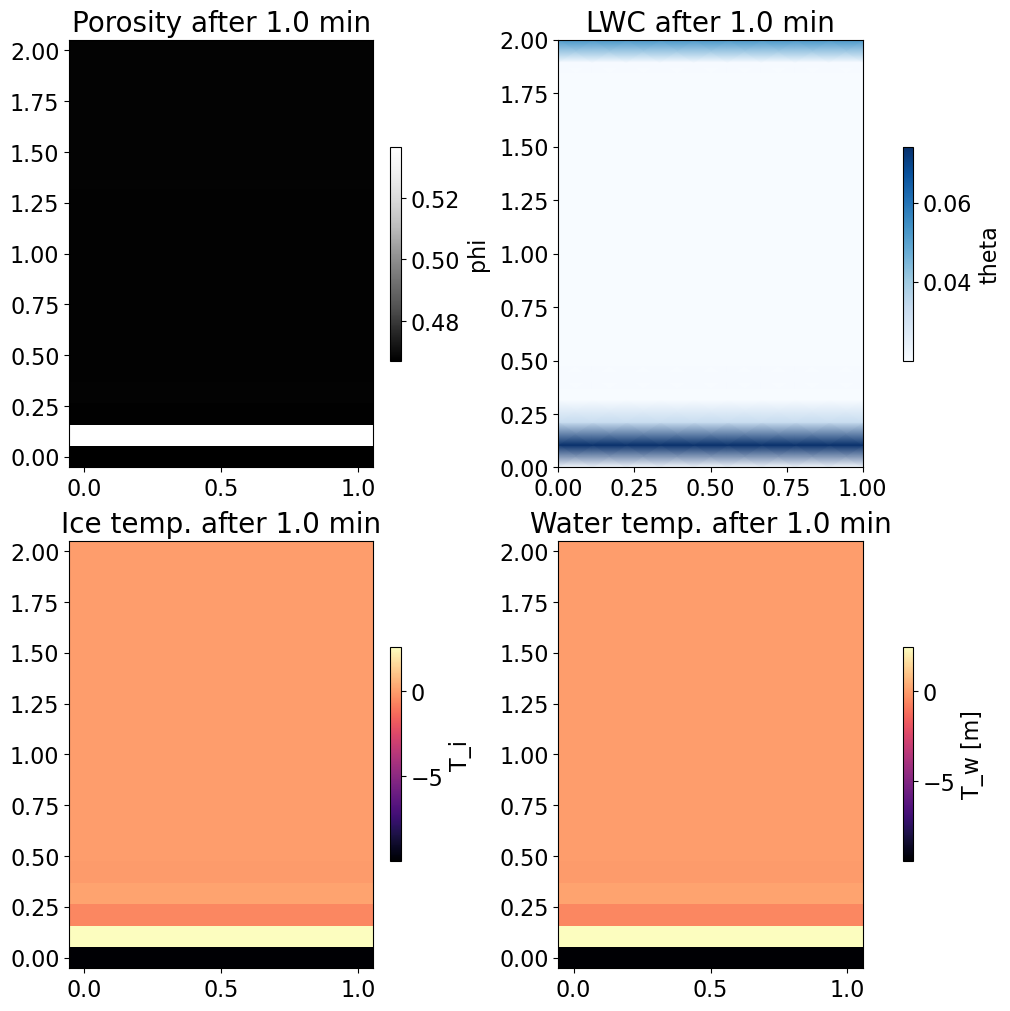

In [28]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(2,2, layout="constrained", figsize=(10,10))
pmsh1 = ax[0,0].pcolormesh(x_plot, z_plot, porosity, cmap="Greys_r")
ax[0,0].set_title(f"Porosity after {time/60:.1f} min", fontsize=20)
cbar1 = fig.colorbar(pmsh1, ax=ax[0,0], shrink=0.5)
cbar1.set_label("phi")
#ax[0,0].set_ylim(1.8,2)

pmsh2 = ax[0,1].pcolormesh(x_plot, z_plot, theta_tot, cmap="Blues", shading="gouraud")
ax[0,1].set_title(f"LWC after {time/60:.1f} min", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh2, ax=ax[0,1], shrink=0.5)
cbar2.set_label("theta")
#ax[0,1].set_ylim(1.8,2)

pmsh3 = ax[1,0].pcolormesh(x_plot, z_plot, Ti, cmap="magma")
ax[1,0].set_title(f"Ice temp. after {time/60:.1f} min", fontsize=20)
cbar1 = fig.colorbar(pmsh3, ax=ax[1,0], shrink=0.5)
cbar1.set_label("T_i")
#ax[1,0].set_ylim(1.8,2)

pmsh4 = ax[1,1].pcolormesh(x_plot, z_plot, Tw, cmap="magma")
ax[1,1].set_title(f"Water temp. after {time/60:.1f} min", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh4, ax=ax[1,1], shrink=0.5)
cbar2.set_label("T_w [m]")
#ax[1,1].set_ylim(1.8,2)

In [11]:
a_i = (p.K_i.value/p.r_i.value)/(p.K_i.value/p.r_i.value + p.K_w.value/p.r_w.value + p.rho_w.value*p.L_sol.value*p.R_m.value)
a_w = (p.K_w.value/p.r_w.value)/(p.K_i.value/p.r_i.value + p.K_w.value/p.r_w.value + p.rho_w.value*p.L_sol.value*p.R_m.value)
print(a_i, a_w)
Tint = a_i*-10+a_w*0
print(Tint+10)


0.93550825764197 0.010058642886630787
0.6449174235802992


In [51]:
60/3600

0.016666666666666666

In [58]:
hwdg0 = Function(Q)
hwdg0.interpolate(hw)
p.W_SSA_numerical(p.S_e_numerical(hwdg0), phi)

array([1.38519217, 1.65312642, 1.3851895 , 1.67565443, 1.65312043,
       1.38519019, 1.64575481, 1.6756557 , 1.65312316, 1.38519393,
       1.66465284, 1.64575907, 1.67565899, 1.65312685, 1.385194  ,
       1.66087865, 1.66465206, 1.64575928, 1.67565882, 1.65312511,
       1.38519311, 1.66570458, 1.66087863, 1.66465156, 1.64575821,
       1.6756582 , 1.65312547, 1.38519403, 1.66755137, 1.66570585,
       1.66087935, 1.66465233, 1.64575902, 1.67565847, 1.65312589,
       1.38519397, 1.67038338, 1.66755148, 1.6657061 , 1.66087987,
       1.66465242, 1.64575894, 1.67565828, 1.65312469, 1.38519308,
       1.67291058, 1.67038381, 1.6675517 , 1.66570616, 1.66087996,
       1.66465235, 1.64575838, 1.67566001, 1.6531245 , 1.38519298,
       1.67552939, 1.67291098, 1.67038418, 1.66755196, 1.6657067 ,
       1.66087926, 1.66465291, 1.64575877, 1.67566098, 1.6531246 ,
       1.67816148, 1.67552966, 1.67291122, 1.67038439, 1.6675522 ,
       1.66570608, 1.66088033, 1.66465165, 1.64575638, 1.67565

In [49]:
1 - p.rho_s.value/p.rho_i.value

np.float64(0.4678998911860718)